# 01 — PA-1: para onde vão os pacientes que se internam fora de casa?

**Story:** US-05 (EP-02) · **Entrada:** `data/processed/matriz_od_municipal_mensal.parquet`
(a matriz origem→destino construída na US-04).

**O contexto.** A US-04 já respondeu *quanto*: em 2025, **50,5% das internações de
2025 aconteceram fora do município onde o paciente mora**. Metade. Esse número, sozinho,
não diz nada ao gestor — sair de casa para se internar pode ser normal (nem todo
município tem hospital) ou pode ser sintoma de uma rede mal distribuída.

**A pergunta desta análise (PA-1):** *para onde* essas pessoas vão?

**A hipótese.** O destino é **altamente concentrado em poucos polos**. Se isso se
confirmar, a implicação para a Secretaria Estadual de Saúde é forte e direta: a rede
hospitalar da Paraíba **não é uma malha** (muitos municípios se ajudando entre si), e
sim um **funil** (quase todo mundo desaguando nos mesmos dois ou três lugares). Malha e
funil pedem políticas opostas — a primeira se ajusta na margem, o segundo exige
descentralizar capacidade instalada.

**Como vamos testar.** Quatro passos, do mais simples ao mais exigente:

1. **Ranking de destinos** — somar o ano inteiro por município de internação e ver quem
   recebe quem;
2. **Medida de concentração** — quantos municípios bastam para explicar 80% e 90% do
   fluxo;
3. **Teste de sensibilidade** — refazer a conta sem os pacientes de fora da Paraíba,
   para garantir que o achado não é um artefato de "gente de outro estado vindo para a
   capital";
4. **Estabilidade mensal** — repetir mês a mês, para garantir que o achado vale o ano
   inteiro e não é um pico sazonal.

**Saídas:** uma tabela (`outputs/tables/pa1_ranking_destinos.csv`), um gráfico
(`outputs/figures/pa1_concentracao_destino.png`) e o **veredito escrito** na última
célula — insumo direto da narrativa executiva (US-16).

## 1. Carregando a matriz e definindo o universo da análise

A matriz da US-04 tem **15.054 linhas**, e cada linha é um par
*(município de residência → município de internação → mês)* com a contagem de
internações. A coluna `evasao_municipal` já vem marcada como `True` quando o paciente
se internou **fora** do município onde mora.

**Decisão de método — quem entra na conta.** A PA-1 pergunta para onde vão *os que se
internam fora de casa*. Então o universo é apenas as linhas com
`evasao_municipal == True`. Quem se internou na própria cidade fica de fora: essa pessoa
não "foi" a lugar nenhum, ela não faz parte do fluxo que queremos mapear. Se
misturássemos os dois grupos, o ranking ficaria inflado justamente nos polos (João
Pessoa tem 800 mil habitantes que se internam na própria cidade) e mediríamos tamanho
de população, não capacidade de atração.

A primeira validação (`assert`) confere que esse recorte dá **130.379 internações** —
número apurado de forma independente antes desta análise. Se divergir, o notebook para
com erro em vez de seguir produzindo um resultado errado.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Caminhos relativos à raiz do projeto (mesmo padrão dos outros notebooks 01-*)
if Path.cwd().name == "notebooks":
    os.chdir("..")

matriz = pd.read_parquet("data/processed/matriz_od_municipal_mensal.parquet")


# Formatação no padrão brasileiro (o Python escreve 43,624.0 — queremos 43.624 e 33,5%)
def br_milhar(valor):
    return f"{int(valor):,}".replace(",", ".")


def br_pct(valor, casas=1):
    return f"{valor:.{casas}f}".replace(".", ",") + "%"


TOTAL_BASE = int(matriz["internacoes"].sum())
print(f"Linhas da matriz O-D: {br_milhar(len(matriz))}")
print(f"Internações representadas (base 2025 inteira): {br_milhar(TOTAL_BASE)}")

# Universo da PA-1: só quem se internou fora do município de residência
fora = matriz[matriz["evasao_municipal"]].copy()
TOTAL_FORA = int(fora["internacoes"].sum())

print(f"\nInternações FORA do município de residência: {br_milhar(TOTAL_FORA)}")
print(f"Isso é {br_pct(100 * TOTAL_FORA / TOTAL_BASE)} de todas as internações de 2025.")

assert TOTAL_FORA == 130379, f"Universo da PA-1 divergiu: {TOTAL_FORA} (esperado 130.379)"
print("\nOK — universo da PA-1 confere: 130.379 internações de não-residentes.")

Linhas da matriz O-D: 15.054
Internações representadas (base 2025 inteira): 258.125

Internações FORA do município de residência: 130.379
Isso é 50,5% de todas as internações de 2025.

OK — universo da PA-1 confere: 130.379 internações de não-residentes.


## 2. O ranking: quem recebe esses pacientes?

Agora agrupamos por **município de internação** (`cod_mun_int`) e somamos o ano inteiro.
Cada município ganha três números:

- `internacoes` — quantos pacientes de fora ele recebeu em 2025;
- `pct` — que fatia do total de 130.379 isso representa;
- `pct_acumulado` — a soma das fatias dele e de todos os que estão acima no ranking.

O **percentual acumulado** é a peça-chave da análise de concentração. Ele responde
diretamente: "os N primeiros colocados juntos respondem por quantos % do fluxo?".
Numa rede bem distribuída, essa coluna sobe devagar (é preciso somar muitos municípios
para chegar perto de 100%). Num funil, ela dispara nas primeiras linhas.

Agrupamos pelo **código IBGE** e não pelo nome porque código é identificador único —
nomes de município se repetem entre estados (existe mais de uma "Santa Rita" no Brasil).
O nome vai junto só como etiqueta legível.

In [2]:
ranking = (
    fora.groupby(["cod_mun_int", "nome_mun_int", "regiao_int"], observed=True)["internacoes"]
    .sum()
    .reset_index()
    .sort_values("internacoes", ascending=False)
    .reset_index(drop=True)
)

ranking["pct"] = (100 * ranking["internacoes"] / TOTAL_FORA).round(2)
ranking["pct_acumulado"] = ranking["pct"].cumsum().round(2)
ranking.insert(0, "posicao", range(1, len(ranking) + 1))

# VALIDAÇÃO OBRIGATÓRIA: o ranking não pode perder nem inventar internação nenhuma
soma_ranking = int(ranking["internacoes"].sum())
print(f"Soma do ranking: {br_milhar(soma_ranking)}")
assert soma_ranking == TOTAL_FORA == 130379, "O ranking não conserva o total de internações!"
print("OK — soma do ranking = 130.379 (nenhuma internação perdida no agrupamento).\n")

print(f"Municípios que receberam ao menos 1 paciente de fora: {len(ranking)}")
ranking.head(15)

Soma do ranking: 130.379
OK — soma do ranking = 130.379 (nenhuma internação perdida no agrupamento).

Municípios que receberam ao menos 1 paciente de fora: 55


,posicao,cod_mun_int,nome_mun_int,regiao_int,internacoes,pct,pct_acumulado
0,1,250750,João Pessoa,1ª Região Mata Atlântica - PB,43624,33.46,33.46
1,2,250400,Campina Grande,16ª Região - PB,32817,25.17,58.63
2,3,251080,Patos,6ª Região - PB,11147,8.55,67.18
3,4,251370,Santa Rita,1ª Região Mata Atlântica - PB,6507,4.99,72.17
4,5,250370,Cajazeiras,9ª Região - PB,4573,3.51,75.68
5,6,250890,Mamanguape,14ª Região - PB,4308,3.30,78.98
6,7,250630,Guarabira,2ª Região - PB,4267,3.27,82.25
7,8,251620,Sousa,10ª Região - PB,2862,2.20,84.45
8,9,251210,Pombal,13ª Região - PB,2504,1.92,86.37
9,10,250430,Catolé do Rocha,8ª Região - PB,2444,1.87,88.24


## 3. Quanto isso é concentrado?

O ranking já mostra o desenho, mas "concentração" precisa virar número. Três medidas
que um gestor entende sem explicação técnica:

1. **Os 2 primeiros colocados juntos** — João Pessoa e Campina Grande, os dois polos
   históricos do estado;
2. **Quantos municípios são necessários para chegar a 80% e a 90%** do fluxo — a leitura
   mais honesta de concentração, porque não depende de escolher um recorte arbitrário;
3. **Quantos municípios da Paraíba sequer aparecem** como local de internação. A PB tem
   **223 municípios**; se a maioria nunca aparece nem como destino nem como sede de
   internação, isso é evidência de que a capacidade instalada simplesmente não existe
   fora dos polos.

> Nota sobre o item 3: contamos os municípios que aparecem como local de internação em
> **qualquer** linha da matriz (inclusive as internações de moradores da própria cidade),
> não só no ranking de não-residentes. É a pergunta "onde existe hospital que faturou
> pelo SUS em 2025?", não "onde existe hospital que atraiu gente de fora?".

In [3]:
# (1) Os polos
top2 = ranking.head(2)
top3 = ranking.head(3)
pct_top2 = top2["internacoes"].sum() / TOTAL_FORA * 100
pct_top3 = top3["internacoes"].sum() / TOTAL_FORA * 100

print("--- Concentração nos polos ---")
for _, linha in top3.iterrows():
    print(
        f"{linha['posicao']}º {linha['nome_mun_int']:<16}"
        f"{br_milhar(linha['internacoes']):>7}"
        f"  ({br_pct(linha['pct'])} do fluxo)"
    )
print(f"\n2 primeiros juntos (João Pessoa + Campina Grande): {br_pct(pct_top2)}")
print(f"3 primeiros juntos (+ Patos):                     {br_pct(pct_top3)}")

# (2) Quantos municípios para 80% e 90%
n_80 = int((ranking["pct_acumulado"] < 80).sum()) + 1
n_90 = int((ranking["pct_acumulado"] < 90).sum()) + 1
print("\n--- Quantos municípios explicam o fluxo ---")
print(f"{n_80} municípios concentram 80% das internações de não-residentes")
print(f"{n_90} municípios concentram 90%")
print(f"{len(ranking)} municípios recebem ALGUM paciente de fora")

# (3) Cobertura: quantos dos 223 municípios da PB têm internação registrada
MUNICIPIOS_PB = 223
munic_com_internacao = matriz["cod_mun_int"].nunique()
print("\n--- Cobertura da rede hospitalar ---")
print(f"Municípios com QUALQUER internação registrada em 2025: {munic_com_internacao} de {MUNICIPIOS_PB}")
print(
    f"Ou seja: {MUNICIPIOS_PB - munic_com_internacao} municípios da PB "
    f"({br_pct(100 * (MUNICIPIOS_PB - munic_com_internacao) / MUNICIPIOS_PB, 0)}) "
    "não registraram nenhuma internação pelo SUS."
)

--- Concentração nos polos ---
1º João Pessoa      43.624  (33,5% do fluxo)
2º Campina Grande   32.817  (25,2% do fluxo)
3º Patos            11.147  (8,6% do fluxo)

2 primeiros juntos (João Pessoa + Campina Grande): 58,6%
3 primeiros juntos (+ Patos):                     67,2%

--- Quantos municípios explicam o fluxo ---
7 municípios concentram 80% das internações de não-residentes
11 municípios concentram 90%
55 municípios recebem ALGUM paciente de fora

--- Cobertura da rede hospitalar ---
Municípios com QUALQUER internação registrada em 2025: 62 de 223
Ou seja: 161 municípios da PB (72%) não registraram nenhuma internação pelo SUS.


## 4. Teste de sensibilidade: e se tirarmos quem não é da Paraíba?

**A objeção que um avaliador crítico faria.** A base do SIH-PB registra internações que
aconteceram em hospitais da Paraíba — inclusive as de gente que mora em outros estados.
Essas pessoas são, por definição, "não-residentes do município de internação", então
entram no nosso universo de 130.379. E é razoável supor que quem vem de longe procure
justamente a capital. **Será que a concentração que medimos é só isso — turismo de saúde
interestadual inflando João Pessoa?**

**Como se testa isso.** Refazendo exatamente a mesma conta com um recorte mais duro:
só pacientes com `uf_res == 'PB'` (residentes do próprio estado). Se a concentração cair
muito, o achado era frágil. Se ficar praticamente igual, o achado é do estado, não dos
visitantes.

Esse tipo de checagem se chama **teste de sensibilidade**: mudar uma premissa e ver se a
conclusão muda junto. Uma conclusão que sobrevive a ele é uma conclusão robusta — e o
registro do teste vira **nota metodológica** no relatório final, antecipando a objeção
em vez de esperar que ela apareça na banca.

In [4]:
fora_pb = fora[fora["uf_res"] == "PB"]
total_fora_pb = int(fora_pb["internacoes"].sum())

ranking_pb = (
    fora_pb.groupby("nome_mun_int", observed=True)["internacoes"]
    .sum()
    .sort_values(ascending=False)
)
pct_top2_pb = ranking_pb.head(2).sum() / total_fora_pb * 100

de_fora_do_estado = TOTAL_FORA - total_fora_pb
print(f"Internações de não-residentes, TODAS:                 {br_milhar(TOTAL_FORA)}")
print(f"Internações de não-residentes, só de quem mora na PB: {br_milhar(total_fora_pb)}")
print(
    f"Diferença (pacientes de outros estados): {br_milhar(de_fora_do_estado)}"
    f" = {br_pct(100 * de_fora_do_estado / TOTAL_FORA)} do universo"
)

print(f"\nTop 2 polos — universo completo: {br_pct(pct_top2)}")
print(f"Top 2 polos — só residentes PB:  {br_pct(pct_top2_pb)}")
print(f"Variação: {pct_top2_pb - pct_top2:+.1f} ponto percentual".replace(".", ","))
print("\nCONCLUSÃO DO TESTE: a concentração praticamente não se move. O achado NÃO é")
print("efeito de pacientes de outros estados — é o padrão dos próprios paraibanos.")

Internações de não-residentes, TODAS:                 130.379
Internações de não-residentes, só de quem mora na PB: 128.877
Diferença (pacientes de outros estados): 1.502 = 1,2% do universo

Top 2 polos — universo completo: 58,6%
Top 2 polos — só residentes PB:  58,5%
Variação: -0,1 ponto percentual

CONCLUSÃO DO TESTE: a concentração praticamente não se move. O achado NÃO é
efeito de pacientes de outros estados — é o padrão dos próprios paraibanos.


## 5. O achado vale o ano inteiro ou é sazonal?

Segunda checagem de robustez. Somar os 12 meses num número só esconde variação: um
achado poderia vir de dois ou três meses atípicos (uma epidemia, um mutirão de cirurgias
na capital) e não representar a rotina da rede.

Então repetimos a conta **mês a mês**: em cada competência de 2025, que fatia das
internações de não-residentes foi para João Pessoa + Campina Grande? Se a linha for
razoavelmente plana, o padrão é **estrutural** — está no desenho da rede, não no
calendário. Estrutural é exatamente o adjetivo que sustenta uma recomendação de
regionalização/PPI: problema de desenho se resolve com política, oscilação sazonal se
resolve com contingência.

In [5]:
COD_JP, COD_CG = "250750", "250400"

mensal = (
    fora.assign(eh_polo=fora["cod_mun_int"].isin([COD_JP, COD_CG]))
    .groupby("mes", observed=True)
    .apply(
        lambda g: pd.Series(
            {
                "internacoes_fora": g["internacoes"].sum(),
                "para_os_2_polos": g.loc[g["eh_polo"], "internacoes"].sum(),
            }
        ),
        include_groups=False,
    )
    .reset_index()
)
mensal["pct_2_polos"] = (100 * mensal["para_os_2_polos"] / mensal["internacoes_fora"]).round(1)

print("Fatia dos 2 polos, mês a mês (2025):")
for _, linha in mensal.iterrows():
    print(f"  mês {int(linha['mes']):>2}: {br_pct(linha['pct_2_polos'])}")

print(
    f"\nMínimo do ano: {br_pct(mensal['pct_2_polos'].min())}"
    f"  |  Máximo: {br_pct(mensal['pct_2_polos'].max())}"
)
amplitude = mensal["pct_2_polos"].max() - mensal["pct_2_polos"].min()
print(f"Amplitude: {amplitude:.1f} pontos percentuais".replace(".", ","))

assert mensal["pct_2_polos"].min() >= 56, "Algum mês caiu abaixo de 56% — revisar a leitura de estabilidade!"
print("\nOK — em NENHUM mês de 2025 os 2 polos ficaram abaixo de 56%. Padrão estável.")

Fatia dos 2 polos, mês a mês (2025):
  mês  1: 61,3%
  mês  2: 59,7%
  mês  3: 58,8%
  mês  4: 59,0%
  mês  5: 58,1%
  mês  6: 57,3%
  mês  7: 57,7%
  mês  8: 57,9%
  mês  9: 60,4%
  mês 10: 58,6%
  mês 11: 58,2%
  mês 12: 56,6%

Mínimo do ano: 56,6%  |  Máximo: 61,3%
Amplitude: 4,7 pontos percentuais

OK — em NENHUM mês de 2025 os 2 polos ficaram abaixo de 56%. Padrão estável.


## 6. Salvando a tabela do ranking

O ranking completo (todos os municípios que receberam ao menos um paciente de fora) vai
para `outputs/tables/` em CSV. Formato escolhido de propósito: CSV abre em qualquer
planilha, o que permite ao Pedro e a qualquer avaliador conferir número por número sem
rodar código. Regra do projeto (RNF-05): **nenhum número da apresentação pode ser
digitado à mão** — todos precisam sair de um arquivo derivável deste notebook.

In [6]:
Path("outputs/tables").mkdir(parents=True, exist_ok=True)
saida_tabela = Path("outputs/tables/pa1_ranking_destinos.csv")
ranking.to_csv(saida_tabela, index=False, encoding="utf-8")
print(f"Salvo: {saida_tabela} ({saida_tabela.stat().st_size / 1024:.1f} KB, {len(ranking)} linhas)")

# Conferência pós-gravação: o arquivo relido ainda soma o universo correto?
relido = pd.read_csv(saida_tabela)
assert int(relido["internacoes"].sum()) == 130379
print("Conferência pós-gravação: CSV relido soma 130.379 internações — OK.")

Salvo: outputs\tables\pa1_ranking_destinos.csv (3.0 KB, 55 linhas)
Conferência pós-gravação: CSV relido soma 130.379 internações — OK.


## 7. A visualização de título-afirmação

**O que é "título-afirmação".** Regra de comunicação do projeto (RNF-04): o título do
gráfico não descreve o eixo ("Internações por município de destino"), ele **afirma o
achado** ("Dois municípios absorvem 59% de..."). Quem só bate o olho no slide já leva a
conclusão; o gráfico serve de prova, não de charada.

**O desenho escolhido.** Dois painéis lado a lado:

- **Esquerda — barras horizontais do top 10.** Barras horizontais (e não verticais)
  porque os nomes dos municípios são longos e ficam legíveis na horizontal, sem girar
  texto. Os dois polos ganham cor destacada; os demais ficam em cinza, para que a
  desproporção salte aos olhos sem precisar de legenda.
- **Direita — curva de acumulado.** Percorre os 55 municípios que recebem gente de fora
  e mostra a que percentual do fluxo chegamos a cada um. Anotações marcam os pontos
  "2 municípios = 58,6%" e "7 municípios = 80%". Uma curva que sobe quase vertical no
  começo **é** a imagem do funil.

Salvamos em 200 dpi (acima do mínimo de 150) para não borrar em projeção. Os números
aparecem no padrão brasileiro (ponto para milhar, vírgula para decimal) graças às duas
funções auxiliares definidas na seção 1 — o Python, por padrão, escreveria `43,624` e
`33.5%`, que é o padrão americano.

Salvo: outputs\figures\pa1_concentracao_destino.png (259 KB, 200 dpi)


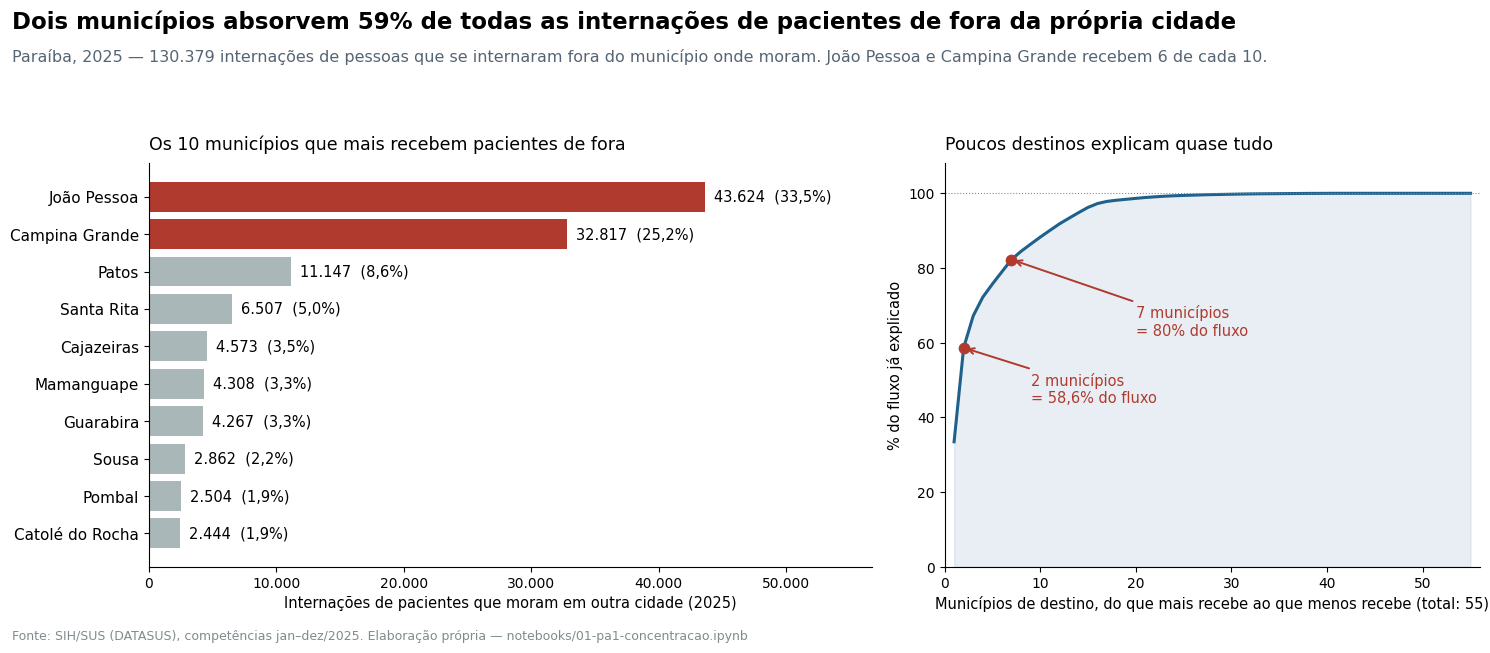

In [7]:
Path("outputs/figures").mkdir(parents=True, exist_ok=True)

top10 = ranking.head(10).iloc[::-1]  # invertido: maior fica no topo do gráfico
COR_POLO, COR_DEMAIS = "#B03A2E", "#AAB7B8"
cores = [COR_POLO if p <= 2 else COR_DEMAIS for p in top10["posicao"]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6.5), gridspec_kw={"width_ratios": [1.35, 1]})

# --- Painel esquerdo: top 10 destinos ---
barras = ax1.barh(top10["nome_mun_int"], top10["internacoes"], color=cores)
for barra, (_, linha) in zip(barras, top10.iterrows()):
    rotulo = f"{br_milhar(linha['internacoes'])}  ({br_pct(linha['pct'])})"
    ax1.text(barra.get_width() + 700, barra.get_y() + barra.get_height() / 2,
             rotulo, va="center", fontsize=10.5)
ax1.set_xlim(0, ranking["internacoes"].max() * 1.30)
ax1.set_xlabel("Internações de pacientes que moram em outra cidade (2025)", fontsize=10.5)
ax1.set_title("Os 10 municípios que mais recebem pacientes de fora",
              fontsize=12.5, loc="left", pad=10)
ax1.tick_params(axis="y", labelsize=11)
for lado in ("top", "right"):
    ax1.spines[lado].set_visible(False)
ax1.xaxis.set_major_formatter(lambda v, _: br_milhar(v))

# --- Painel direito: curva de acumulado ---
ax2.plot(ranking["posicao"], ranking["pct_acumulado"], color="#1F618D", linewidth=2.2)
ax2.fill_between(ranking["posicao"], ranking["pct_acumulado"], color="#1F618D", alpha=0.10)
ax2.scatter([2, n_80], [ranking.loc[1, "pct_acumulado"], ranking.loc[n_80 - 1, "pct_acumulado"]],
            color="#B03A2E", zorder=5, s=55)
ax2.annotate(f"2 municípios\n= {br_pct(pct_top2)} do fluxo",
             xy=(2, ranking.loc[1, "pct_acumulado"]), xytext=(9, 44),
             fontsize=10.5, color="#B03A2E",
             arrowprops=dict(arrowstyle="->", color="#B03A2E", lw=1.4))
ax2.annotate(f"{n_80} municípios\n= 80% do fluxo",
             xy=(n_80, ranking.loc[n_80 - 1, "pct_acumulado"]), xytext=(20, 62),
             fontsize=10.5, color="#B03A2E",
             arrowprops=dict(arrowstyle="->", color="#B03A2E", lw=1.4))
ax2.axhline(100, color="#7F8C8D", linewidth=0.8, linestyle=":")
ax2.set_xlim(0, len(ranking) + 1)
ax2.set_ylim(0, 108)
ax2.set_xlabel(f"Municípios de destino, do que mais recebe ao que menos recebe (total: {len(ranking)})",
               fontsize=10.5)
ax2.set_ylabel("% do fluxo já explicado", fontsize=10.5)
ax2.set_title("Poucos destinos explicam quase tudo", fontsize=12.5, loc="left", pad=10)
for lado in ("top", "right"):
    ax2.spines[lado].set_visible(False)

fig.suptitle(
    f"Dois municípios absorvem {pct_top2:.0f}% de todas as internações de pacientes de fora da própria cidade",
    fontsize=16.5, fontweight="bold", x=0.011, ha="left", y=0.985,
)
fig.text(
    0.011, 0.905,
    "Paraíba, 2025 — 130.379 internações de pessoas que se internaram fora do município onde moram. "
    "João Pessoa e Campina Grande recebem 6 de cada 10.",
    fontsize=11.5, color="#566573", ha="left",
)
fig.text(
    0.011, 0.015,
    "Fonte: SIH/SUS (DATASUS), competências jan–dez/2025. Elaboração própria — notebooks/01-pa1-concentracao.ipynb",
    fontsize=9, color="#7F8C8D", ha="left",
)

fig.tight_layout(rect=[0, 0.035, 1, 0.875])
saida_fig = Path("outputs/figures/pa1_concentracao_destino.png")
fig.savefig(saida_fig, dpi=200, bbox_inches="tight", facecolor="white")
print(f"Salvo: {saida_fig} ({saida_fig.stat().st_size / 1024:.0f} KB, 200 dpi)")
plt.show()

## 8. Veredito da PA-1

### Hipótese **CONFIRMADA**

**Em linguagem simples:** em 2025, 130.379 internações da Paraíba foram de pessoas que
tiveram de se internar fora da cidade onde moram — cerca de metade de todas as
internações do estado. A pergunta era para onde essas pessoas vão, e a resposta é
concentrada a ponto de ser desconfortável: **João Pessoa recebeu 33,5% e Campina Grande
25,2% — juntas, 58,6%, quase 6 de cada 10**. Somando Patos, chega-se a 67,2%. Bastam
**7 municípios para explicar 80%** desse deslocamento, e **11 para explicar 90%**;
apenas 55 municípios recebem algum paciente de fora, e apenas **62 dos 223 municípios da
Paraíba registraram qualquer internação pelo SUS no ano** — ou seja, em mais de 7 de
cada 10 cidades do estado não houve internação nenhuma. A rede hospitalar paraibana,
vista pelo caminho que o paciente percorre, **não funciona como uma malha de municípios
que se apoiam mutuamente; funciona como um funil que despeja quase todo mundo em dois
endereços**. Esse é o argumento central para a Secretaria Estadual de Saúde: enquanto a
capacidade instalada permanecer assim, qualquer pactuação regional continuará, na
prática, sendo uma pactuação com João Pessoa e Campina Grande.

O achado sobreviveu às duas checagens que poderiam derrubá-lo. **Tirando os pacientes de
outros estados** (que poderiam estar inflando artificialmente a capital), a fatia dos
dois polos cai de 58,6% para **58,5%** — variação de um décimo, conclusão intacta.
**Mês a mês**, os dois polos oscilam entre **56,6% e 61,3%**, sem nunca cair abaixo de
56%: não é pico sazonal nem efeito de um mês atípico, é o comportamento do ano inteiro.

### Limitações declaradas

1. **Cada linha é uma internação, não uma pessoa.** O SIH conta AIH (autorizações de
   internação). Um mesmo paciente internado três vezes aparece três vezes. Os números
   medem volume de deslocamento assistencial, não quantidade de indivíduos.
2. **Só enxergamos hospitais da Paraíba.** Paraibanos internados em Pernambuco, Rio
   Grande do Norte ou Ceará estão nos arquivos daqueles estados e não entram aqui. A
   concentração medida é a concentração *dentro* do estado — é um piso; a dimensão
   interestadual é o objeto da US-08.
3. **Só internações pelo SUS.** A rede privada/suplementar não está no SIH. Em municípios
   com mais leitos privados, o retrato do SUS pode subestimar a oferta local total.
4. **Concentração não é, por si só, um defeito.** Parte dela é esperada e até desejável:
   procedimentos de alta complexidade *devem* ser concentrados, porque exigem escala para
   ter qualidade e segurança. O que esta análise mostra é o *tamanho* do funil; separar
   o deslocamento justificado (alta complexidade) do evitável (média complexidade que
   deveria existir na região) exige olhar o tipo de internação — trabalho previsto na
   US-20 (EP-07).
5. **Distância não foi medida.** Parte da "evasão" de municípios como Santa Rita e Bayeux
   é conurbação com João Pessoa: o paciente atravessa a rua, não o estado. O peso disso
   está mapeado nos maiores pares origem→destino da US-04 e deve ser lembrado ao
   interpretar o volume da capital.

### Números para a narrativa executiva (US-16)

| Número | Valor |
|---|---|
| Internações fora do município de residência (2025) | 130.379 |
| João Pessoa | 43.624 (33,5%) |
| Campina Grande | 32.817 (25,2%) |
| **Os 2 polos juntos** | **58,6%** |
| Com Patos (3 polos) | 67,2% |
| Municípios para 80% do fluxo | 7 |
| Municípios para 90% do fluxo | 11 |
| Municípios que recebem algum paciente de fora | 55 |
| Municípios da PB com qualquer internação registrada | 62 de 223 |
| Sensibilidade (só residentes PB) — 2 polos | 58,5% |
| Estabilidade mensal — 2 polos | entre 56,6% e 61,3% |